In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Gibbs sampler
# -----------------------------
def sample_rbm(W, b, c, v0=None, nsteps=100, key=None):
    """
    Gibbs sampler for a binary RBM.

    Args:
        W: (Nv, Nh) weight matrix
        b: (Nh,) hidden biases
        c: (Nv,) visible biases
        v0: optional initial visible vector (Nv,)
        nsteps: number of Gibbs steps
        key: JAX PRNGKey

    Returns:
        v: final visible vector
        h: final hidden vector
        traj: list of (v,h) pairs along the chain
    """
    Nv, Nh = W.shape
    if key is None:
        key = jax.random.PRNGKey(0)
    if v0 is None:
        key, subkey = jax.random.split(key)
        v = jax.random.bernoulli(subkey, 0.5, shape=(Nv,)).astype(jnp.float32)
    else:
        v = v0.astype(jnp.float32)

    traj = []

    for _ in range(nsteps):
        # sample hidden given visible
        key, subkey = jax.random.split(key)
        h_prob = jax.nn.sigmoid(v @ W - b)
        h = jax.random.bernoulli(subkey, h_prob).astype(jnp.float32)

        # sample visible given hidden
        key, subkey = jax.random.split(key)
        v_prob = jax.nn.sigmoid(W @ h - c)
        v = jax.random.bernoulli(subkey, v_prob).astype(jnp.float32)

        traj.append((v, h))

    return v, h, traj

In [7]:
def physicalH(W, grid_shape=None):
    
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings
    return J_physical

h2set, HistSet = [], []
rbm_param = []
files = ['pprbmnh256.pkl','aprbmnh256.pkl','PArbmnh256.pkl','AArbmnh256.pkl']
for file in files:
    with open(file, 'rb') as handle:
        my_dict = pickle.load(handle)
        rbm_param.append((my_dict['W'],my_dict['bv'],my_dict['bh']))
        h2set.append(physicalH(my_dict['W']))
        HistSet.append(my_dict['history'])

In [9]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random, jit, vmap
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
import mcfile as mcf
import pickle
from scipy.spatial.distance import cdist
import pandas as pd

In [11]:
sectors = ['PP', 'PA', 'AP', 'AA']
n_runs_per_sector = 3  

b_c = 0.440687
#sizes = [24, 32, 48, 64]
#L = sizes[0]
Lx, Ly = 24, 32

datadir = "ising_nonsquare_critical"
data = mcf.build_dataframe(datadir)
bc_num = data['beta'][np.argmin(np.abs(np.array(data['beta'])-b_c))]


# Identify the exact beta matching critical temperature
bc_num = data['beta'][np.argmin(np.abs(np.array(data['beta']) - b_c))]

bc_num

Processing files: 100%|█| 80/80 [00:05<00:00, 15.32file/s, L32_beta0.441000_sect


np.float64(0.44077777777777777)

In [16]:
from ensemble_rbm import load_ensemble_results

In [27]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising16_rbm_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

In [37]:
ens_results['PP'][2].keys()

dict_keys(['run', 'W', 'bv', 'bh', 'history_train', 'history_val'])

In [42]:
hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        hamiltonian_data[sector].append((instance['W'],instance['bv'],instance['bh']))

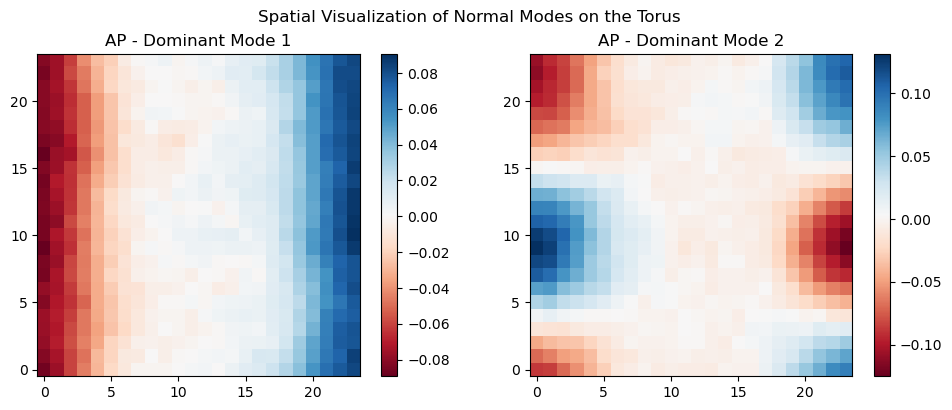


Sector: AP
-> Top 3 Eigenvalues: [1.4347732 1.0911123]
-> Generated configurations matrix shape: (5, 576)


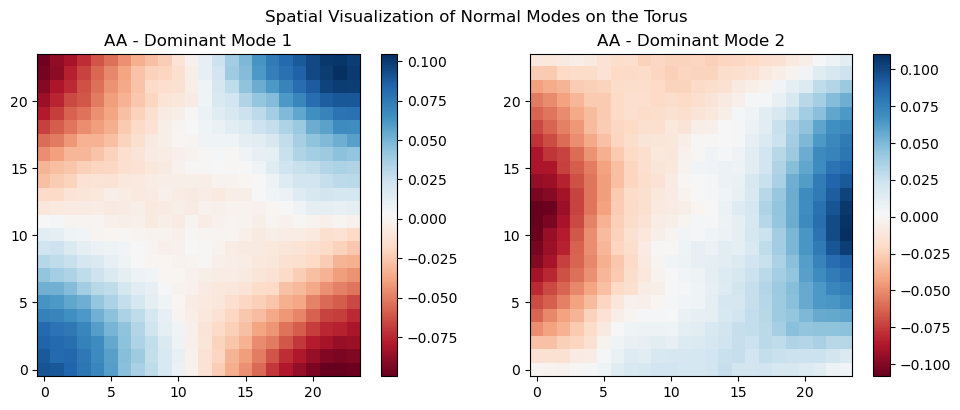


Sector: AA
-> Top 3 Eigenvalues: [1.6470511 1.5216066]
-> Generated configurations matrix shape: (5, 576)


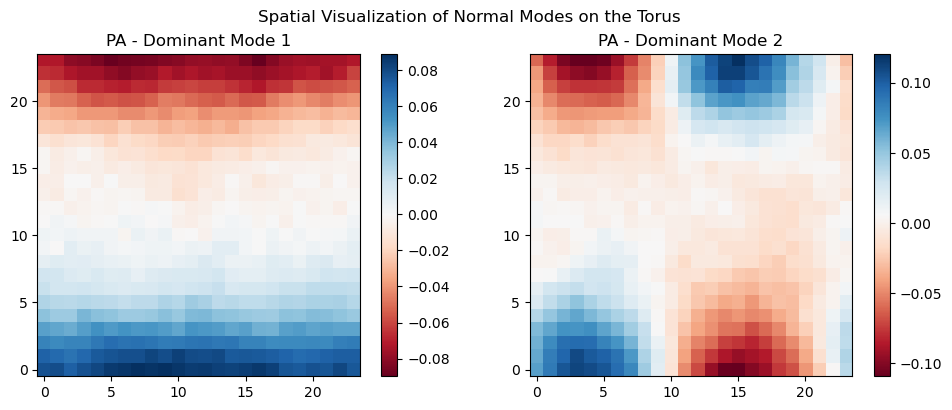


Sector: PA
-> Top 3 Eigenvalues: [1.4410452 1.0657625]
-> Generated configurations matrix shape: (5, 576)


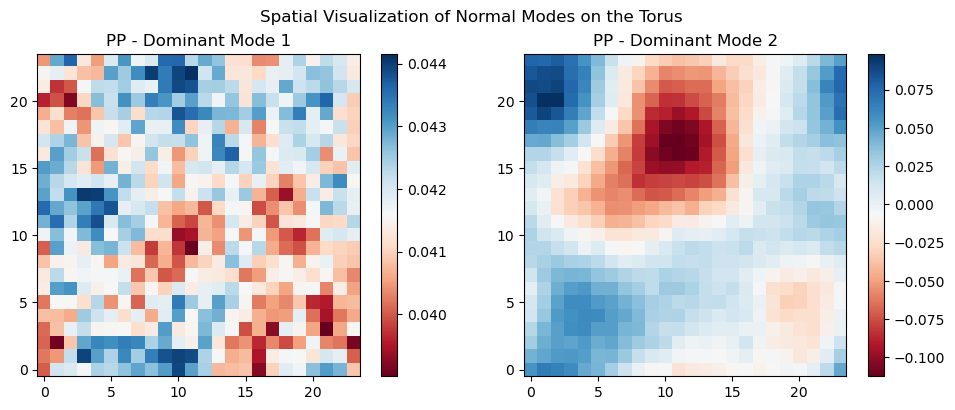


Sector: PP
-> Top 3 Eigenvalues: [2.2599192 0.4629688]
-> Generated configurations matrix shape: (5, 576)


In [121]:
import jax
import jax.numpy as jnp
from jax import jit

def visualize_torus_modes(U_K, sector_name, L=16):
    """
    Plots the top 2 principal components as 2D spatial maps on the torus.
    U_K shape: (V, K) where V = L*L
    """
    # Extract the first two principal components
    mode_1 = U_K[:, 0].reshape(L, L)
    mode_2 = U_K[:, 1].reshape(L, L)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mode 1
    im1 = axes[0].imshow(mode_1, cmap='RdBu', origin='lower')
    axes[0].set_title(f"{sector_name} - Dominant Mode 1")
    fig.colorbar(im1, ax=axes[0])
    
    # Mode 2
    im2 = axes[1].imshow(mode_2, cmap='RdBu', origin='lower')
    axes[1].set_title(f"{sector_name} - Dominant Mode 2")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Spatial Visualization of Normal Modes on the Torus")
    plt.tight_layout()
    plt.show()

@jit
def compute_weak_coupling_J(W, bh):
    """
    Computes the effective pairwise J matrix in the small-weight limit
    when W is shaped as (H, V).
    """
    # W shape: (H, V) where H is hidden, V is visible
    H, V = W.shape
    
    # Compute the variance of the hidden units: shape (H,)
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma) 
    
    # Scale the weights across the hidden dimension.
    # Since W is (H, V) and variance is (H,), we broadcast along the first axis.
    # variance[:, None] gives shape (H, 1), which broadcasts perfectly over (H, V)
    W_scaled = W * jnp.sqrt(variance)[:, None]
    
    # Since W_scaled is (H, V), to get a (V, V) interaction matrix,
    # we take the dot product of its transpose with itself: (V, H) @ (H, V)
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # Zero out diagonal to avoid self-interaction loops
    #J = J * (1.0 - jnp.eye(V))
    return J

def sample_from_sector_pca(key, sector_instances, K, num_samples=1000):
    """
    Computes a collective PCA basis for a given sector by averaging its 
    analytic J matrices, then samples configurations along those top K modes.
    """
    # Grab dimensions from the first instance
    sample_W, sample_bv, sample_bh = sector_instances[0]
    H, V = sample_W.shape
    
    # 1. Accumulate and average the analytic J matrices across all instances in this sector
    J_total = jnp.zeros((V, V))
    for W, bv, bh in sector_instances:
        # Ensure data is converted to device arrays
        W_arr = jnp.array(W, dtype=jnp.float32)
        bh_arr = jnp.array(bh, dtype=jnp.float32)
        J_total += compute_weak_coupling_J(W_arr, bh_arr)
        
    J_avg = J_total / len(sector_instances)
    J_avg = (J_avg+J_avg.T)/2
    
    # 2. Extract principal components via EIGH
    eigenvalues, eigenvectors = jnp.linalg.eigh(J_avg)
    
    # Sort from largest to smallest eigenvalue
    eigenvalues = jnp.flip(eigenvalues)
    U = jnp.flip(eigenvectors, axis=1)
    
    # Truncate to top K principal directions
    U_K = U[:, :K]
    sigma_K = jnp.sqrt(jnp.abs(eigenvalues[:K])) # Standard deviation of the modes
    
    # 3. Sample continuous fluctuations in the latent subspace
    k1, k2 = jax.random.split(key)
    latent_samples = jax.random.normal(k1, (num_samples, K)) * sigma_K[None, :]
    
    # 4. Project back to physical real-space and squash to binary boundaries [0, 1]
    # We use a neutral 0.5 background mean for the spins
    v_mean = 0.5 * jnp.ones((V,))
    v_continuous = v_mean[None, :] + jnp.dot(latent_samples, U_K.T)
    v_sampled_configs = jax.nn.sigmoid(v_continuous)
    
    return v_sampled_configs, U_K, eigenvalues

UKlist = []
eigen = []
# --- Execution Over All Sectors ---
if __name__ == "__main__":
    import numpy as np
            
    # Process and sample
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 2  # Keep the top 4 dominant modes
    
    sampled_results = {}
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        v_samples, U_K, spectrum = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        sampled_results[sector] = v_samples
        visualize_torus_modes(U_K, sector,24)
        UKlist.append(U_K)
        print(f"\nSector: {sector}")
        print(f"-> Top 3 Eigenvalues: {spectrum[:K_modes]}")
        eigen.append(spectrum[:K_modes])
        print(f"-> Generated configurations matrix shape: {v_samples.shape}")

In [112]:
Lambda = jnp.outer(jnp.exp(-eigen[0]/2),jnp.exp(eigen[0]/2))
Span = UKlist[0].T@UKlist[0]

dot_estimate0 = jnp.trace(Lambda *Span)
dot_estimate0

Array(1.9999998, dtype=float32)

In [115]:
Lambda = jnp.outer(jnp.exp(-eigen[0]/2),jnp.exp(eigen[1]/2))
Span = UKlist[0].T@UKlist[1]

dot_estimate01 = jnp.trace(Lambda *Span)
dot_estimate01/jnp.sqrt(dot_estimate1*dot_estimate0)

Array(-0.21318677, dtype=float32)

In [113]:
Lambda = jnp.outer(jnp.exp(-eigen[1]/2),jnp.exp(eigen[1]/2))
Span = UKlist[1].T@UKlist[1]

dot_estimate1 = jnp.trace(Lambda *Span)
dot_estimate1

Array(2.000001, dtype=float32)

In [97]:
Lambda = jnp.outer(jnp.exp(-eigen[2]/2),jnp.exp(eigen[2]/2))
Span = UKlist[2].T@UKlist[2]

dot_estimate2 = jnp.trace(Lambda *Span)
dot_estimate2

Array(1.9999995, dtype=float32)

In [107]:
Lambda = jnp.outer(jnp.exp(eigen[2]/2),jnp.exp(eigen[1]/2))
Span = UKlist[2].T@UKlist[1]

dot_estimate12 = jnp.trace(Lambda *Span)
dot_estimate12

Array(-1.8680644, dtype=float32)

In [108]:
dot_estimate12/(jnp.sqrt(dot_estimate1)*jnp.sqrt(dot_estimate2))

Array(-0.9340321, dtype=float32)

In [103]:
Lambda = jnp.outer(jnp.exp(-eigen[1]/2),jnp.exp(eigen[2]/2))
Span = UKlist[1].T@UKlist[2]

dot_estimate21 = jnp.trace(Lambda *Span)
dot_estimate21

Array(-0.6251638, dtype=float32)

In [105]:
dot_estimate21/(jnp.sqrt(dot_estimate1)*jnp.sqrt(dot_estimate2))

Array(-0.31258187, dtype=float32)

In [ ]:
# --- Execution Over All Sectors ---
if __name__ == "__main__":
    import numpy as np
            
    # Process and sample
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 10  # Keep the top 4 dominant modes
    
    sampled_results = {}
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        v_samples, U_K, spectrum = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        sampled_results[sector] = v_samples
        visualize_torus_modes(U_K, sector)
        
        print(f"\nSector: {sector}")
        print(f"-> Top 3 Eigenvalues: {spectrum[:3]}")
        print(f"-> Generated configurations matrix shape: {v_samples.shape}")

In [50]:
J = compute_weak_coupling_J(W,bh)
J.shape

(256, 256)

In [18]:
import jax
import jax.numpy as jnp
from jax import jit

@jit
def compute_gaussian_metric_matrix(W, bh):
    """
    Computes the effective continuous metric matrix G = I - 4J
    directly from the W shape (H, V).
    """
    H, V = W.shape
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma)
    
    # Scaled matrix product matching the weak-coupling J
    W_scaled = W * jnp.sqrt(variance)[:, None]
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # G = I - 4J
    return jnp.eye(V) - 4.0 * J

@jit
def compute_analytic_fidelity(W1, bh1, W2, bh2):
    """
    Computes the exact normalized inner product between two RBM sectors
    using the continuous determinant formula. Completely avoids sampling!
    """
    G1 = compute_gaussian_metric_matrix(W1, bh1)
    G2 = compute_gaussian_metric_matrix(W2, bh2)
    
    # Compute the average metric for the numerator cross-term
    G_avg = 0.5 * (G1 + G2)
    
    # Use logdet for numerical stability
    _, logdet_G1 = jnp.linalg.slogdet(G1)
    _, logdet_G2 = jnp.linalg.slogdet(G2)
    _, logdet_G_avg = jnp.linalg.slogdet(G_avg)
    
    # Log-fidelity formula: 0.25*logdet(G1) + 0.25*logdet(G2) - 0.5*logdet(G_avg)
    log_fidelity = 0.25 * logdet_G1 + 0.25 * logdet_G2 - 0.5 * logdet_G_avg
    
    return jnp.exp(log_fidelity)

In [23]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising16_rbm_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

In [25]:
hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        hamiltonian_data[sector].append((instance['W'],instance['bv'],instance['bh']))
Wap, bvap, bhap = hamiltonian_data['AP'][0]
Wpa, bvpa, bhpa = hamiltonian_data['PA'][0]

In [30]:
import jax
import jax.numpy as jnp
from jax import jit

def stabilize_metric_matrix(G, epsilon=1e-6):
    """
    Stabilizes the metric matrix G by ensuring all its eigenvalues 
    are strictly positive, cutting off unphysical negative noise.
    """
    # Diagonalize G to inspect its eigenvalues
    eigenvalues, eigenvectors = jnp.linalg.eigh(G)
    
    # Clip eigenvalues so they cannot be less than epsilon (must be positive-definite)
    clipped_eigenvalues = jnp.clip(eigenvalues, a_min=epsilon)
    
    # Reconstruct the clean, stable version of G
    G_stable = jnp.dot(eigenvectors * clipped_eigenvalues[None, :], eigenvectors.T)
    return G_stable

@jit
def compute_analytic_fidelity_stable(W1, bh1, W2, bh2, epsilon=1e-4):
    """
    Computes the exact normalized inner product using a stabilized 
    eigenvalue spectrum to guarantee the fidelity stays bounded in [0, 1].
    """
    # 1. Compute raw metrics
    G1_raw = compute_gaussian_metric_matrix(W1, bh1)
    G2_raw = compute_gaussian_metric_matrix(W2, bh2)
    
    # 2. Enforce positive-definiteness
    G1 = stabilize_metric_matrix(G1_raw, epsilon)
    G2 = stabilize_metric_matrix(G2_raw, epsilon)
    G_avg = 0.5 * (G1 + G2)
    
    # 3. Compute log-determinants safely
    _, logdet_G1 = jnp.linalg.slogdet(G1)
    _, logdet_G2 = jnp.linalg.slogdet(G2)
    _, logdet_G_avg = jnp.linalg.slogdet(G_avg)
    
    # Log-fidelity evaluation
    log_fidelity = 0.25 * logdet_G1 + 0.25 * logdet_G2 - 0.5 * logdet_G_avg
    
    # Clip to absolute physical bounds to account for rounding floating-point issues
    return jnp.clip(jnp.exp(log_fidelity), a_min=0.0, a_max=1.0)

In [31]:
compute_analytic_fidelity_stable(Wap, bhap, Wpa, bhpa)

Array(1.3149439e-06, dtype=float32)

In [11]:
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt
from ensemble_rbm import load_ensemble_results
from jax import jit

In [117]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising_576_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        hamiltonian_data[sector].append((instance['W'],instance['bv'],instance['bh']))

(576, 20)


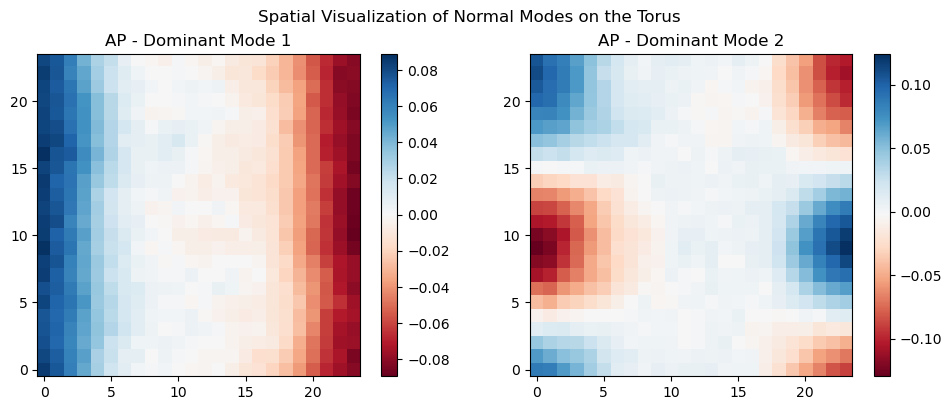


Sector: AP
-> Top 3 Eigenvalues: [1.3886201  1.0444125  0.95498914 0.74050325 0.70251405 0.6728741
 0.6400163  0.6022365  0.57167566 0.5240266  0.4990589  0.4893134
 0.48723534 0.43726912 0.42615154 0.4122214  0.3941215  0.37668756
 0.36631224 0.35302284]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


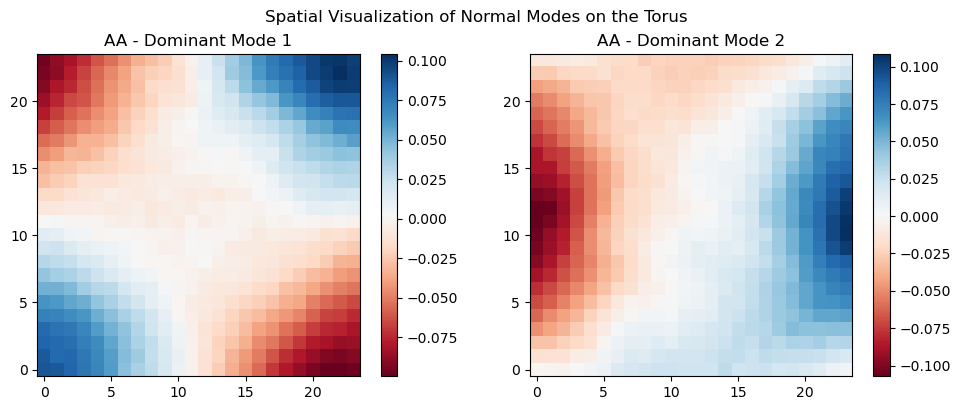


Sector: AA
-> Top 3 Eigenvalues: [1.5837617  1.4600512  1.4390324  0.99906975 0.97891337 0.96310824
 0.92992777 0.8814545  0.8227268  0.81772643 0.80181384 0.75215304
 0.7138612  0.68912363 0.67561644 0.6488607  0.62543344 0.6225683
 0.6115622  0.58943206]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


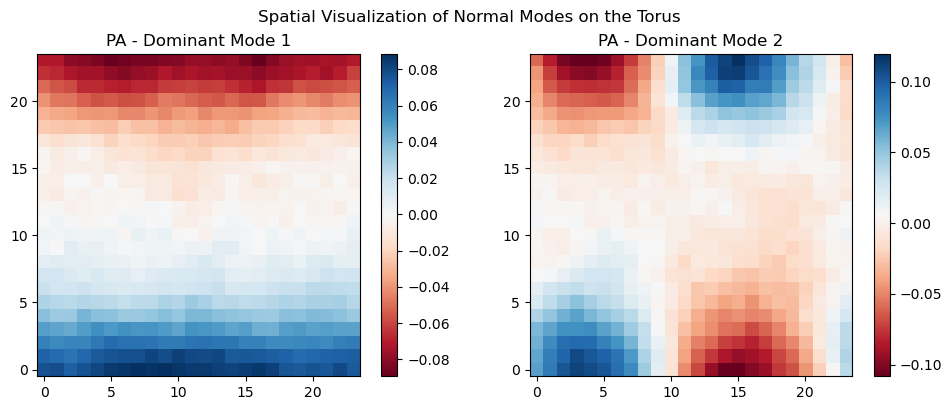


Sector: PA
-> Top 3 Eigenvalues: [1.3964351  1.0213951  0.94248915 0.6906458  0.66466963 0.64705473
 0.61244696 0.5775093  0.5593604  0.53199553 0.511247   0.49632135
 0.46701792 0.4406479  0.42543522 0.39252335 0.38606927 0.3712303
 0.36847246 0.3611316 ]
-> Generated configurations matrix shape: (5, 576)
(576, 20)


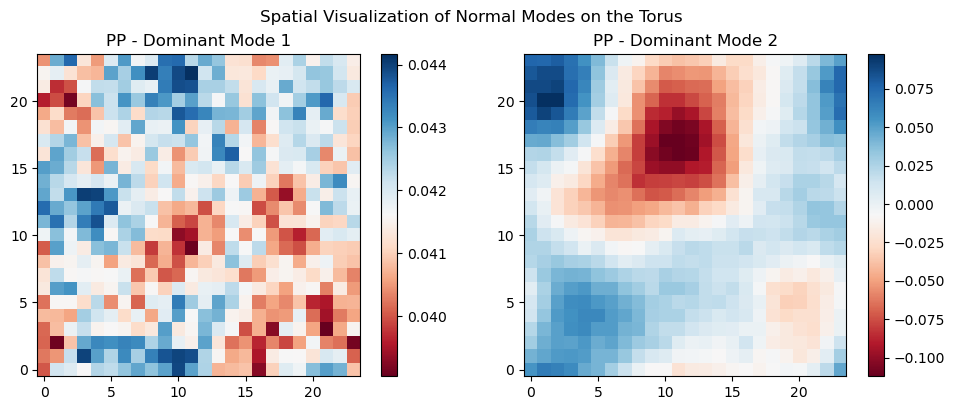


Sector: PP
-> Top 3 Eigenvalues: [2.237169   0.44007856 0.42483738 0.4121616  0.4003378  0.39574614
 0.39021608 0.3831414  0.37318575 0.34963349 0.34304    0.33592474
 0.3266233  0.31913072 0.31812316 0.3051639  0.30039036 0.29562786
 0.28398257 0.2783494 ]
-> Generated configurations matrix shape: (5, 576)


In [119]:
def visualize_torus_modes(U_K, sector_name, L=24):
    """
    Plots the top 2 principal components as 2D spatial maps on the torus.
    U_K shape: (V, K) where V = L*L
    """
    # Extract the first two principal components
    mode_1 = U_K[:, 0].reshape(L, L)
    mode_2 = U_K[:, 1].reshape(L, L)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mode 1
    im1 = axes[0].imshow(mode_1, cmap='RdBu', origin='lower')
    axes[0].set_title(f"{sector_name} - Dominant Mode 1")
    fig.colorbar(im1, ax=axes[0])
    
    # Mode 2
    im2 = axes[1].imshow(mode_2, cmap='RdBu', origin='lower')
    axes[1].set_title(f"{sector_name} - Dominant Mode 2")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Spatial Visualization of Normal Modes on the Torus")
    plt.tight_layout()
    plt.show()

@jit
def compute_weak_coupling_J(W, bh):
    """
    Computes the effective pairwise J matrix in the small-weight limit
    when W is shaped as (H, V).
    """
    # W shape: (H, V) where H is hidden, V is visible
    H, V = W.shape
    
    # Compute the variance of the hidden units: shape (H,)
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma) 
    
    # Scale the weights across the hidden dimension.
    # Since W is (H, V) and variance is (H,), we broadcast along the first axis.
    # variance[:, None] gives shape (H, 1), which broadcasts perfectly over (H, V)
    W_scaled = W * jnp.sqrt(variance)[:, None]
    
    # Since W_scaled is (H, V), to get a (V, V) interaction matrix,
    # we take the dot product of its transpose with itself: (V, H) @ (H, V)
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # Zero out diagonal to avoid self-interaction loops
    J = J * (1.0 - jnp.eye(V))
    return J

def sample_from_sector_pca(key, sector_instances, K, num_samples=1000):
    """
    Computes a collective PCA basis for a given sector by averaging its 
    analytic J matrices, then samples configurations along those top K modes.
    """
    # Grab dimensions from the first instance
    sample_W, sample_bv, sample_bh = sector_instances[0]
    H, V = sample_W.shape
    
    # 1. Accumulate and average the analytic J matrices across all instances in this sector
    J_total = jnp.zeros((V, V))
    for W, bv, bh in sector_instances:
        # Ensure data is converted to device arrays
        W_arr = jnp.array(W, dtype=jnp.float32)
        bh_arr = jnp.array(bh, dtype=jnp.float32)
        J_total += compute_weak_coupling_J(W_arr, bh_arr)
        
    J_avg = J_total / len(sector_instances)
    
    # 2. Extract principal components via EIGH
    eigenvalues, eigenvectors = jnp.linalg.eigh(J_avg)
    
    # Sort from largest to smallest eigenvalue
    eigenvalues = jnp.flip(eigenvalues)
    U = jnp.flip(eigenvectors, axis=1)
    
    # Truncate to top K principal directions
    U_K = U[:, :K]
    sigma_K = jnp.sqrt(jnp.abs(eigenvalues[:K])) # Standard deviation of the modes
    
    # 3. Sample continuous fluctuations in the latent subspace
    k1, k2 = jax.random.split(key)
    latent_samples = jax.random.normal(k1, (num_samples, K)) * sigma_K[None, :]
    
    # 4. Project back to physical real-space and squash to binary boundaries [0, 1]
    # We use a neutral 0.5 background mean for the spins
    v_mean = 0.5 * jnp.ones((V,))
    v_continuous = v_mean[None, :] + jnp.dot(latent_samples, U_K.T)
    v_sampled_configs = jax.nn.sigmoid(v_continuous)
    
    return v_sampled_configs, U_K, eigenvalues

# --- Execution Over All Sectors ---
if __name__ == "__main__":
    import numpy as np
            
    # Process and sample
    rng_key = jax.random.PRNGKey(1234)
    K_modes = 20  # Keep the top 4 dominant modes
    
    sampled_results = {}
    for sector, instances in hamiltonian_data.items():
        rng_key, subkey = jax.random.split(rng_key)
        
        v_samples, U_K, spectrum = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
        print(U_K.shape)
        sampled_results[sector] = v_samples
        visualize_torus_modes(U_K, sector)
        
        print(f"\nSector: {sector}")
        print(f"-> Top 3 Eigenvalues: {spectrum[:K_modes]}")
        print(f"-> Generated configurations matrix shape: {v_samples.shape}")

In [ ]:
Lambda = jnp.outer(jnp.exp(-eigen[0]/2),jnp.exp(eigen[0]/2))
Span = UKlist[0].T@UKlist[0]

dot_estimate0 = jnp.trace(Lambda *Span)
dot_estimate0

In [ ]:
Lambda = jnp.outer(jnp.exp(-eigen[1]/2),jnp.exp(eigen[1]/2))
Span = UKlist[1].T@UKlist[1]

dot_estimate1 = jnp.trace(Lambda *Span)
dot_estimate1

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_covariance_torus(H, Lx, Ly, ax = None, threshold_percentile=98, R=3.0, r=1.0):
    """
    Maps a periodic 2D lattice onto a 3D Torus and plots covariance links between sites.
    
    Parameters:
        data: np.array or jnp.array of shape (n_samples, n_visible)
        grid_shape: tuple (height, width). Assumed square if None.
        threshold_percentile: Top % of absolute covariance connections to draw.
        R: float, major radius of the torus (distance from center of tube to center of donut).
        r: float, minor radius of the torus (radius of the tube itself).
    """
    cov_matrix = H
    width = Lx
    height = Ly
    abs_cov = np.abs(H)
    
    threshold = np.percentile(abs_cov, threshold_percentile)

    # 2. Map 2D grid coordinates to 3D Torus parametric space
    # Theta wraps around the ring (width), Phi wraps around the tube (height)
    theta = np.linspace(0, 2 * np.pi, width, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, height, endpoint=False)
    
    Theta, Phi = np.meshgrid(theta, phi)
    Theta = Theta.ravel()
    Phi = Phi.ravel()

    # Parametric equations for a torus
    X = (R + r * np.cos(Phi)) * np.cos(Theta)
    Y = (R + r * np.cos(Phi)) * np.sin(Theta)
    Z = r * np.sin(Phi)
    
    coords_3d = np.vstack([X, Y, Z]).T # Shape: (n_visible, 3)

    if ax is None:
        # 3. Setup 3D Plot if not already specified into a subplot
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

    # Plot the lattice nodes on the surface of the torus
    ax.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2], 
               color='lightgray', s=20, alpha=0.8, edgecolors='gray', zorder=5)

    # 4. Filter and draw the links
    ii, jj = np.where(abs_cov > threshold)
    seen_edges = set()
    max_val = np.max(abs_cov)

    for i, j in zip(ii, jj):
        if (i, j) in seen_edges or (j, i) in seen_edges:
            continue
        seen_edges.add((i, j))

        val = cov_matrix[i, j]
        abs_val = abs_cov[i, j]
        
        edge_color = 'dodgerblue' if val > 0 else 'crimson'
        line_width = (abs_val / max_val) *0.5 if val >0 else 1 #* 3.0
        alpha_val = 0.2 + 0.8 * (abs_val / max_val)

        # Draw the 3D link bridging site i and site j across the surface
        ax.plot(
            [coords_3d[i, 0], coords_3d[j, 0]], 
            [coords_3d[i, 1], coords_3d[j, 1]], 
            [coords_3d[i, 2], coords_3d[j, 2]], 
            color=edge_color, 
            linewidth=line_width, 
            alpha=alpha_val,
            zorder=4
        )
    
    # Balance axes proportions so the donut doesn't stretch weirdly
    max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
    mid_x = (X.max()+X.min()) / 2.0
    mid_y = (Y.max()+Y.min()) / 2.0
    mid_z = (Z.max()+Z.min()) / 2.0
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    #ax.dist = 1
    #zoom = 0.75
    
    zoom = 0.6   # smaller -> bigger torus
    
    ax.set_xlim(mid_x - zoom * max_range,
                mid_x + zoom * max_range)
    ax.set_ylim(mid_y - zoom * max_range,
                mid_y + zoom * max_range)
    ax.set_zlim(mid_z - zoom * max_range,
                mid_z + zoom * max_range)
    ax.dist = 6
    ax.set_box_aspect([1,1,1])
    
    ax.axis('off')
    return ax



In [149]:
def physicalH(W, grid_shape=None):
    
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings
    return J_physical

In [151]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/ising16_rbm_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

compute_J = {}

hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    compute_J[sector]= []
    for instance in ens:
        W, bv, bh = (instance['W'],instance['bv'],instance['bh'])
        print(W.shape)
        W, bv, bh = jnp.mean(W,axis=0), jnp.mean(bv,axis=0), jnp.mean(bh,axis=0)
        hamiltonian_data[sector].append((W,bv,bh))
        print(W.shape)
        compute_J[sector].append(physicalH(W.reshape(16,16)))

(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)
(16, 256)
(256,)


In [156]:
compute_J.keys()

dict_keys(['AA', 'AP', 'PA', 'PP'])

In [160]:
h2set = {} 
for key, val in compute_J.items():
    h2set[key]= np.mean(np.asarray(val),axis =0)
h2set.keys()

dict_keys(['AA', 'AP', 'PA', 'PP'])

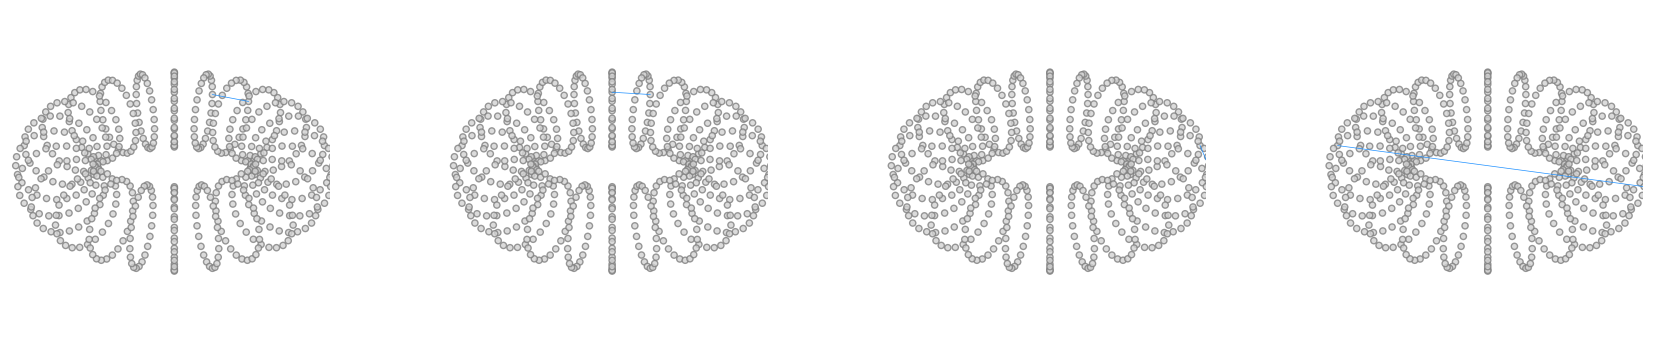

In [161]:
filename = 'rbm_hamiltonian_torus.pdf'

key = ['PP', 'AP','PA', 'AA']
fig = plt.figure(figsize=(18, 3.5))

axes = []
for i in range(4):
    # Create a 3D subplot explicitly
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    axes.append(ax)

# Loop over your Hamiltonians / covariances
for i, J_physical in enumerate(h2set.values()):
    axes[i] = visualize_covariance_torus(J_physical, Lx=24, Ly=24,
                               ax=axes[i],
                               threshold_percentile=99)
plt.tight_layout()
plt.savefig(filename)
plt.show()

In [163]:
J_physical

array([[0.        , 0.02277065, 0.02238134, 0.02173945, 0.02120426,
        0.02073841, 0.02052723, 0.02052119, 0.02102788, 0.01990771,
        0.02017464, 0.02128059, 0.02146204, 0.02264639, 0.02163587,
        0.02214306],
       [0.02277065, 0.        , 0.02258557, 0.02194704, 0.02145848,
        0.02099859, 0.02066784, 0.02069954, 0.02116776, 0.02005813,
        0.0204111 , 0.02140527, 0.02165104, 0.02283742, 0.02176394,
        0.02224181],
       [0.02238134, 0.02258557, 0.        , 0.02158688, 0.02107018,
        0.02067401, 0.0203892 , 0.02044472, 0.02092884, 0.01977376,
        0.02005324, 0.02097947, 0.02120287, 0.02238188, 0.02135914,
        0.02186072],
       [0.02173945, 0.02194704, 0.02158688, 0.        , 0.02062937,
        0.02036586, 0.02013205, 0.02020425, 0.02063992, 0.0195535 ,
        0.01973645, 0.02059906, 0.02078825, 0.02183154, 0.02082115,
        0.02124842],
       [0.02120426, 0.02145848, 0.02107018, 0.02062937, 0.        ,
        0.02007906, 0.01982123, 

In [164]:
import pickle

In [165]:
h2set, HistSet = [], []
files = ['pprbmnh256.pkl','aprbmnh256.pkl','PArbmnh256.pkl','AArbmnh256.pkl']
for file in files:
    with open(file, 'rb') as handle:
        my_dict = pickle.load(handle)
        h2set.append(physicalH(my_dict['W']))
        HistSet.append(my_dict['history'])

In [166]:
h2set[0].shape

(576, 576)

In [ ]:
def analyze_physical_hamiltonian(W, filename, grid_shape=None):
    """
    Visualizes the physical Hamiltonian coupling matrix (W^T * W) 
    and plots its interaction strengths as a function of real 2D spatial distance.
    
    Parameters:
        W: jnp.array or np.array, the weight matrix of shape (n_hidden, n_visible)
        grid_shape: tuple (height, width), spatial dimensions of your visible layer.
                    If None, assumes a square grid based on n_visible.
    """
    # 1. Convert JAX array to standard NumPy for plotting
    W_np = np.array(W)
    n_hidden, n_visible = W_np.shape
    
    if grid_shape is None:
        side = int(np.sqrt(n_visible))
        grid_shape = (side, side)
        assert grid_shape[0] * grid_shape[1] == n_visible, \
            f"Visible dimension {n_visible} is not a perfect square. Please specify grid_shape."

    # 2. Compute the physical Hamiltonian coupling matrix (W^T * W)
    # This represents the effective quadratic interactions between pixels
    J_physical = np.dot(W_np.T, W_np)
    np.fill_diagonal(J_physical, 0)  # Zero out self-interactions to isolate couplings

    # 3. Map visible units to actual 2D spatial coordinates
    x = np.arange(grid_shape[1])
    y = np.arange(grid_shape[0])
    X, Y = np.meshgrid(x, y)
    coordinates = np.vstack([Y.ravel(), X.ravel()]).T  # Shape: (n_visible, 2)

    # 4. Compute all pairwise 2D Euclidean distances between units
    distances = cdist(coordinates, coordinates, metric='euclidean')

    # Flatten both matrices to 1D arrays of length (n_visible * n_visible)
    flat_distances = distances.ravel()
    flat_couplings = J_physical.ravel()

    # ─── Plotting ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
    
    # Plot 1: The full Physical Hamiltonian Matrix
    im1 = axes[0].imshow(J_physical, cmap='bwr', aspect='equal')
    #axes[0].set_title(f"Physical Hamiltonian ($W^TW$)\nShape: {J_physical.shape}")
    axes[0].set_xlabel("Visible Unit Index")
    axes[0].set_ylabel("Visible Unit Index")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: Coupling Strength vs 2D Distance Histogram
    counts, xedges, yedges, im2 = axes[1].hist2d(flat_distances, 
                                                 flat_couplings, bins=200, 
                                                 cmap='viridis', cmin=1,alpha=0.7)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    #axes[1].set_title("Interaction Strength vs. Spatial Distance")
    axes[1].set_xlabel("2D Spatial Distance (Pixels)")
    axes[1].set_ylabel("Coupling Value ($W^TW_{ij}$)")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="Density Counts")
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()